## DEEP LEARNING FOR FINANCE


MODULE 1 | LESSON 2


---

# **Multilayer Perceptron: Market Timing in APPL Stock** 

|  |  |
|:---|:---|
|**Reading Time** |  60 minutes |
|**Prior Knowledge** | MLP, Market timing, Python  |
|**Keywords** | MLP, Classification, Neural Network, Dropout |


---

*In this lesson we will start increasing the complexity of our Neural Networks by considering more dense MLPs that incorporate features such as **Dropout** in order to enhance its performance. Also, different from the regression example we used in the Machine Learning course on timing the Momentum factor, we will deal here with a **classification** problem. Specifically, we will try to design a strategy that times the return of Apple stock ('AAPL'). For that, we will employ an MLP network that aims to predict whether the future return of AAPL is positive or negative. Based on the predictions from the model, we will later on check how our strategy performs.*

## **1. Data and sources**

As with any other Deep Learning endeavor, the single most important and necessary ingredient is data. Different from what we did in the Momentum timing example, in this case we will retrieve Apple stock price data from Yahoo! Finance using the famous **yfinance** library in Python, which you are already familiar with:

# Darell Moodley inserted this code

In [1]:
# !pip install keras-tuner
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
import numpy as np

2025-09-24 07:55:33.743440: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 07:55:33.796784: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-24 07:55:35.377415: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
n_data = 5000

# Create a simple dataset for demonstration
# We'll use a regression problem, where y = 2x + 1 with some noise.
X = np.random.rand(n_data, 1) * 10
y = 2 * X + 1 + np.random.randn(n_data, 1) * 2

# Split data into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
def build_model(hp):
    model = keras.Sequential()
    
    # Input layer
    model.add(keras.layers.Input(shape=(1,)))

    # Hyperparameter search for the number of hidden layers

    for i in range(hp.Int('num_layers', min_value=5, max_value=60, step=5)):
        model.add(tf.keras.layers.Dense(units=15, activation='relu'))

    # Output layer
    model.add(keras.layers.Dense(units=1))

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mean_absolute_error'])
    
    return model

In [ ]:

### correct answer
for i in range(hp.Int('num_layers', min_value=5, max_value=60, step=5)):
    model.add(tf.keras.layers.Dense(units=15, activation='relu'))

In [4]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_mean_absolute_error',
    max_trials=5,  # The number of models to test
    executions_per_trial=2, # Number of times to run each model to reduce variance
    directory='my_dir',
    project_name='tuning_hidden_layers')

# # Run the search
tuner.search(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

# # Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"The optimal number of hidden layers is: {best_hps.get('num_layers')}")

# # Get the best model
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Reloading Tuner from my_dir/tuning_hidden_layers/tuner0.json
The optimal number of hidden layers is: 45


/usr/local/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 186 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 15)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 15)             │           24

 Total params: 10,606 (41.43 KB)

 Trainable params: 10,606 (41.43 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the CSV file
file_path = 'AAPL.csv'
df = pd.read_csv(file_path, delimiter=';', decimal=',', parse_dates=['Date'], date_format='%m/%d/%y')
df = df.sort_values('Date')
df = df.set_index('Date')

df.head()

,Price,CVol,Change,% Change,% Return,Total Return (Gross),Cumulative Return %,Open,High,Low,Cumulative Change %
Date,,,,,,,,,,,
1980-12-12,0.13,46903360.0,0.13,NaN,NaN,0.13,NaN,NaN,0.13,0.13,NaN
1980-12-15,0.12,17588480.0,-0.01,-5.22,-5.22,0.12,"-5,22",NaN,0.12,0.12,"-5,22"
1980-12-16,0.11,105728.0,-0.01,-7.32,-7.32,0.11,"-12,16",NaN,0.11,0.11,"-12,16"
1980-12-17,0.12,8644160.0,0.00,2.48,2.48,0.12,"-9,98",NaN,0.12,0.12,"-9,98"
1980-12-18,0.12,7344960.0,0.00,2.86,2.86,0.12,"-7,40",NaN,0.12,0.12,"-7,40"


In [3]:
# Rename '% Return' column to 'Ret'
df = df.rename(columns={'% Return': 'Ret'})

# Define the name variable
name = 'Ret'

# Set 'Date' as index and keep only 'Ret' column
df = df.dropna()

df.head()

,Price,CVol,Change,% Change,Ret,Total Return (Gross),Cumulative Return %,Open,High,Low,Cumulative Change %
Date,,,,,,,,,,,
1991-12-02,0.46,118899320.0,0.01,1.97,1.97,0.48,"276,80",0.45,0.46,0.45,"260,13"
1991-12-03,0.45,102860910.0,-0.01,-2.42,-2.42,0.47,"267,70",0.46,0.46,0.45,"251,44"
1991-12-05,0.45,99198490.0,0.00,-0.99,-0.99,0.47,"264,06",0.45,0.46,0.44,"247,96"
1991-12-06,0.44,196985780.0,-0.01,-2.50,-2.50,0.46,"254,96",0.44,0.44,0.43,"239,26"
1991-12-09,0.44,97832080.0,0.00,0.77,0.77,0.46,"257,69",0.44,0.45,0.44,"241,87"


We will retrieve daily stock price data from AAPL (Apple Inc.) from January 1st, 1980, but we keep only data that do not have any missing observations, reducing the sample size substantially.

Once we have daily prices, we can compute daily returns, which will be used to construct the inputs (and output) of our MLP:

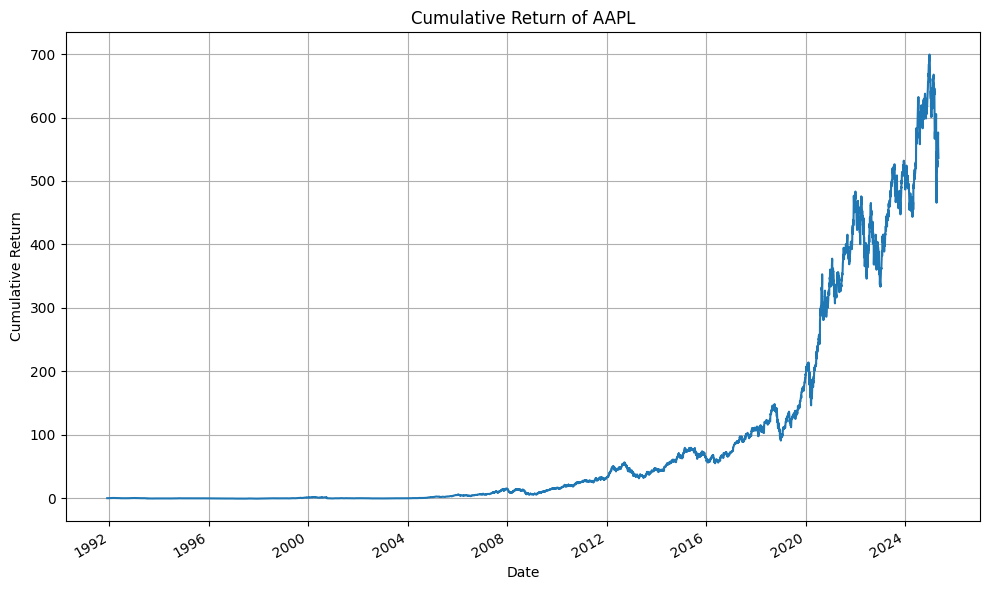

In [4]:
# Calculate cumulative return
df['Cumulative Return'] = (1 + df['Ret'] / 100).cumprod() - 1

# Plot the cumulative return
plt.figure(figsize=(10, 6))
df['Cumulative Return'].plot()
plt.title('Cumulative Return of AAPL')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.tight_layout()
plt.show()

## **2. Timing Apple stock with Multilayer Perceptron (MLPs)**

As we have already mentioned, the purpose of our MLP is to predict the future return (we will shortly see for which time horizon and how) of AAPL using past returns. Hence, one of the first things we must do is decide and define the inputs and outputs of the model.

### **2.1 Inputs and outputs**

As you already know, there are multiple choices to make when selecting the inputs of a MLP model. Some of them are based on sound theory, but also some simply stem from a trial and error process. In this case, we will apply a very similar approach to what we did when building our models for factor momentum timing and consider as inputs in the network the stock returns from the past 25, 60, 90, 120 and 240 days. Once again, after going over and understanding the entire notebook here, please feel free to play around with these time frames or even add more/less inputs into the MLP to see how its performance changes. 

In [5]:
df = df[['Ret']]

df["Ret25_i"] = df[name].rolling(25).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df["Ret60_i"] = df[name].rolling(60).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df["Ret90_i"] = df[name].rolling(90).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df["Ret120_i"] = df[name].rolling(120).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df["Ret240_i"] = df[name].rolling(240).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))

df = df.dropna()
df.tail(10)

,Ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i
Date,,,,,,
2025-04-23,2.43,-3.795072,-10.881083,-17.324816,-11.375229,13.166308
2025-04-24,1.84,-3.186662,-12.437332,-15.363482,-10.514112,14.812281
2025-04-25,0.44,-2.242569,-12.454764,-15.498093,-10.228100,15.098768
2025-04-28,0.41,-3.719238,-11.440489,-15.210988,-8.459465,14.426408
2025-04-29,0.51,-4.309509,-10.388438,-15.764123,-6.287033,15.809066
2025-04-30,0.61,-5.026928,-6.678198,-16.064459,-4.444495,14.500296
2025-05-01,0.39,-3.703195,-8.241178,-13.894452,-3.686575,14.238568
2025-05-02,-3.74,-8.267882,-11.549127,-17.690963,-7.887429,8.640630
2025-05-05,-3.15,-8.729653,-14.608582,-21.754709,-10.493604,5.155357


**Defining the output: Classification**

Finally, we need to define our output label/s. We have decided to focus on the $+120$ (trading) days return for Apple stock. Remember that in this case we will perform a classification task with out MLP model, so that we simply aim to predict whether, on a given time $t$, the return of AAPL from $t$ to $t+120$ days will be positive or negative (note how a zero return, although unlikely, will also be classified as negative). 

Therefore, we first investigate, at a given time $t$, what would be the 120-day return on AAPL. Then, we calculate our output variable, keeping in mind that we will be running a classification task and, hence, we need to convert our output variable to a $0, 1$ variable ($0$ for negative 120 days return, $1$ for positive):

In [6]:
df["Ret120"] = df["Ret120_i"].shift(-120)
df["Output"] = df["Ret120"] > 0
df["Output"] = df["Output"].astype(int)
del df["Ret120"]
df = df.dropna()
df.tail(10)

,Ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i,Output
Date,,,,,,,
2025-04-23,2.43,-3.795072,-10.881083,-17.324816,-11.375229,13.166308,0
2025-04-24,1.84,-3.186662,-12.437332,-15.363482,-10.514112,14.812281,0
2025-04-25,0.44,-2.242569,-12.454764,-15.498093,-10.228100,15.098768,0
2025-04-28,0.41,-3.719238,-11.440489,-15.210988,-8.459465,14.426408,0
2025-04-29,0.51,-4.309509,-10.388438,-15.764123,-6.287033,15.809066,0
2025-04-30,0.61,-5.026928,-6.678198,-16.064459,-4.444495,14.500296,0
2025-05-01,0.39,-3.703195,-8.241178,-13.894452,-3.686575,14.238568,0
2025-05-02,-3.74,-8.267882,-11.549127,-17.690963,-7.887429,8.640630,0
2025-05-05,-3.15,-8.729653,-14.608582,-21.754709,-10.493604,5.155357,0


It is always useful to see some summary statistics of the different variables in our model. We can very easily observe them with the '**.describe()**' feature in Python:

In [7]:
df.describe()

,Ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i,Output
count,8035.000000,8035.000000,8035.000000,8035.000000,8035.000000,8035.000000,8035.000000
mean,0.113769,2.878347,7.260452,11.143045,15.113084,32.569285,0.691599
std,2.699816,13.394873,21.601984,27.569107,33.106180,56.024248,0.461862
min,-51.870000,-69.598132,-77.074930,-72.483802,-74.729250,-75.007329,0.000000
25%,-1.160000,-4.860311,-5.001998,-5.042512,-4.139412,-6.002929,0.000000
50%,0.100000,2.831957,7.050250,10.625607,14.641836,29.047810,1.000000
75%,1.375000,10.547327,19.246392,26.021418,30.664592,59.045564,1.000000
max,33.230000,121.286374,116.442841,135.727260,167.513049,300.683525,1.000000


### **2.2 Train-Test samples and Scaling**

Next important step in building our model is in defining our train and test samples, together with the scaling of variables. As we have usually done before, we will take 20% of observations and devote them to testing, while 80% will be used for training the model. Please note, once again, the importance of doing this in chronological order!

In [8]:
# Train-test split
ts = int(0.2 * len(df))  # Number of observations in test sample (20%)
split_time = len(df) - ts  # Start of test sample
test_time = df.index[split_time:]  # Extract Date index for test period
Ret_vector = df['Ret'][split_time:].values  # Extract Ret values for test period
df.tail()

,Ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i,Output
Date,,,,,,,
2025-04-30,0.61,-5.026928,-6.678198,-16.064459,-4.444495,14.500296,0
2025-05-01,0.39,-3.703195,-8.241178,-13.894452,-3.686575,14.238568,0
2025-05-02,-3.74,-8.267882,-11.549127,-17.690963,-7.887429,8.640630,0
2025-05-05,-3.15,-8.729653,-14.608582,-21.754709,-10.493604,5.155357,0
2025-05-06,-0.19,-10.636714,-12.675026,-22.144726,-12.535408,4.934575,0


Now we are ready to use **sklearn** to formally define the input and output matrices for training (**X_train** and **y_train**) and test (**X_test** and **y_test**). One more time, make sure you keep the 'shuffle' option set to 'False'! 

In [9]:
from sklearn.model_selection import train_test_split

Xdf, ydf = df.iloc[:, 1:-1], df.iloc[:, -1]
X = Xdf.astype("float32")
y = ydf.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=ts, shuffle=False
)  # It is important to keep "shuffle=False"
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(6428, 5) (1607, 5) (6428,) (1607,)


The last 'print' in the previous chunk of code gives as an output very useful information specially for a later time where we will move on to more complex models. In this case, we know that we have $6,428$ observations in training for $5$ different input series. Just as a concept check, could you say how many observations are in the test sample? 

- **What about scaling?**

As you see, we have not implemented scaling here. Scaling of variables is actually a very good practice that we recommend you always follow. In this case, since we are working with returns from the same stock, the impact that scaling of inputs will have is presumably very limited. (To be clear, we use 'scaled' data by taking prices that adjust for any dividends and stock splits).  Nonetheless, we leave this task to you. Once you have completed the whole notebook, come back here and scale input variables to see whether model performance changes by a lot. Feel free to go back to the last module of Machine Learning, where we introduced scaling.

### **2.3 Model and Training**

Finally, it is time to set up our model. In this case, we will use 3 hidden layers with 25, 15 and 10 units respectively, and a final single-unit output layer. For all the hidden layers, we will use a **ReLU** activation function, whereas we will opt for a **sigmoid** activation in the output layer. 

- **Dropout**

Novel to MLP models we have used before (in the Machine Learning course), we are here introducing a **dropout layer** after each of the hidden layers. As you already know, dropout randomly sets some units of a hidden layer to zero. The question of how many units (i.e., frequency rate) is up to the user to define. In this case, we set **n_dropout = 0.2** to shut down 20% of the units in the layer. You can find more info on how the dropout layers work in the official Keras documentation:
https://keras.io/api/layers/regularization_layers/dropout/

- **Loss function?**

So far, we have dealt with regression problems where we used loss functions based on Mean Squared Error (MSE) or Mean Absolute Error (MAE). But now we are in a classification problem with 2 labels (0, 1), so we select a loss function, **binary cross-entropy** that is essentially a log-likelihood:

\
\begin{equation*}
H(y_i) = - \frac{1}{N} \sum_{i=1}^N y_i \ log(p(y_i)) \ + \ (1-y_i) \ log(1-p(y_i))
\end{equation*}

\
For more information on how this loss function works, check the **official documentation** in Keras: https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy

A simple explanation of binary cross-entropy may be found here: https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a

- **Metric for loss function?**

Still, one question remains about which metric would we use for our loss function based on binary cross-entropy. A **metric** is simply a function that is used to judge the performance of your model. See all metrics available in Keras here: https://keras.io/api/metrics/

Here, we choose to judge our model performance using '**accuracy**', which in this case corresponds to binary accuracy:
https://keras.io/api/metrics/accuracy_metrics/#binaryaccuracy-class


In [10]:
import tensorflow as tf

tf.keras.backend.clear_session()  # We clear the backend to reset the random seed process
tf.random.set_seed(
    1234
)  # We will set a random seed so that results obtained are somewhat replicable

act_fun = "relu"
hp_units = 25
hp_units_2 = 15
hp_units_3 = 10
n_dropout = 0.2

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=hp_units, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=hp_units_2, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=hp_units_3, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

hp_lr = 1e-5  # Learning rate

adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)  # Adam optimizer

model.compile(optimizer=adam, loss="binary_crossentropy", metrics=["accuracy"])

2025-05-07 07:31:19.938792: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-07 07:31:19.983019: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-07 07:31:21.038369: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### **2.3.1 Validation and callbacks (Earlystopping)**

We have already built our model, but there are still a few questions that need an answer when training it: how many epochs do we train for? when does the model stop?

To solve these questions, we will use **EarlyStopping**, a method you are already familiar with (feel free to revisit the documentation for Module 7 of Machine Learning). In this case the variable that we will monitor will be model accuracy in the validation set. Naturally, we will aim to obtain the maximum accuracy in validation, and set the patience to 20, so that model training will stop after 20 epochs in which there is no improvement in the accuracy that the model weights yield in the validation set. 

In [11]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    verbose=1,
    patience=20,
    restore_best_weights=True,
)

### **2.3.2 Classification on imbalance data: class_weight**

When we work on classification tasks, there is always the possibility that one of the labels we are trying to predict is underrepresented in the training sample. Ideally you would want the model to give a heavier weight to underrepresented labels so that you do not overlook this in future prediction. For example, suppose that you are trying to predict corporate default, but your data has very small percentage of observation when a firm actually defaults. You may want the model to pay more attention to these observations where the actual action occurs. For that, we can use **class_weights**. 

**Class-weights** essentially consist on passing Keras a weight for each class in the sample, so that we can make the model focus on a particular class more than it will based on its representation in the sample.

Here you have a complete tutorial on how to perform these kind of tasks that use imbalance data in Keras. Please note that his tutorial covers a wide range of topics that we will eventually cover as well. In order not to get lost in details that are not important for now, we suggest you focus on the 'Class weights' section: https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=en


In this case, we would like the model to pay more attention to labels of 0, which correspond to days in which the 120-day-ahead return is negative. There are many ways to assign and modify class weights, we follow here a simple one, completely discretionary:

In [12]:
class_weight = {0: (np.mean(y_train) / 0.5) * 1.2, 1: 1.0}
print(class_weight)

{0: 1.6312382698059082, 1: 1.0}


\
Finally, we are ready to train our model with all these ingredients!

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    verbose=2,
    callbacks=[es],
    class_weight=class_weight,
)

Epoch 1/500
161/161 - 1s - 9ms/step - accuracy: 0.5998 - loss: 5.6416 - val_accuracy: 0.7706 - val_loss: 1.2708
Epoch 2/500
161/161 - 0s - 3ms/step - accuracy: 0.5862 - loss: 5.3652 - val_accuracy: 0.7714 - val_loss: 1.1826
Epoch 3/500
161/161 - 1s - 4ms/step - accuracy: 0.5994 - loss: 5.3257 - val_accuracy: 0.7706 - val_loss: 1.0847
Epoch 4/500
161/161 - 0s - 2ms/step - accuracy: 0.5838 - loss: 5.1315 - val_accuracy: 0.7714 - val_loss: 0.9956
Epoch 5/500
161/161 - 0s - 2ms/step - accuracy: 0.5957 - loss: 4.7177 - val_accuracy: 0.7722 - val_loss: 0.9188
Epoch 6/500
161/161 - 0s - 2ms/step - accuracy: 0.5867 - loss: 4.6330 - val_accuracy: 0.7714 - val_loss: 0.8548
Epoch 7/500
161/161 - 0s - 2ms/step - accuracy: 0.5932 - loss: 4.4603 - val_accuracy: 0.7706 - val_loss: 0.7948
Epoch 8/500
161/161 - 0s - 2ms/step - accuracy: 0.5685 - loss: 4.3878 - val_accuracy: 0.7698 - val_loss: 0.7364
Epoch 9/500
161/161 - 0s - 2ms/step - accuracy: 0.5762 - loss: 4.1500 - val_accuracy: 0.7621 - val_loss:

As usual, let's also inspect the summary of the model layers, which in the presence of dropout makes much more sense to have clear in mind:

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,135 (8.34 KB)

 Trainable params: 711 (2.78 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,424 (5.57 KB)

Note that the presence of the dropout layer does not interfere with the number of parameters in the model. This is because dropout neither adds nor reduces the number of model parameters (or units) as whole, as units are randomly shut down during training epochs, but of course the unit affected is not always the same!

\
This section concludes all relative to the construction and training of the MLP classification model. Now, as we have usually done, let's explore if we could use this model, which achieves a decent accuracy in the validation set, to build a trading strategy:<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

## **3. Financial performance of the model**

As we have done before, let's now evaluate the use of this model for a financial strategy. It is very important that we clearly understand that evaluating the **financial performance** is a completely separate thing from evaluating the **predictive performance** of the model. Obviously, the two tasks are interrelated, but they may offer completely different conclusions after a thorough analysis. We have already trained our model and assess its fit. Now, we will check if the predictions delivered in the test sample are valid for developing a trading strategy!

### **3.1 Model performance in test sample**
We will start by obtaining the predictions of the model in the test sample and its accuracy. Remember, we are evaluating how well our model predicts, using past AAPL returns for 5 different windows, whether the next 120 days returns is positive or negative. The way we will operate is defining model prediction as a 1 (i.e., positive return) if the probability assigned by the model is higher than 0.5; and 0 (i.e., negative return) else.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

y_prob = model.predict(X_test)
y_pred = np.where(y_prob > 0.50, 1, 0)

acc = model.evaluate(X_test, y_test)
print("Model accuracy in test: ", acc)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7859 - loss: 0.6321 
Model accuracy in test:  [0.9570235013961792, 0.6950840353965759]


As you can see, we obtain a very decent accuracy of the model in the test sample. But we would also like to see when does the model 'miss', and when it is mostly 'right' about a prediction. For that, we come to our old friend, the confusion matrix:

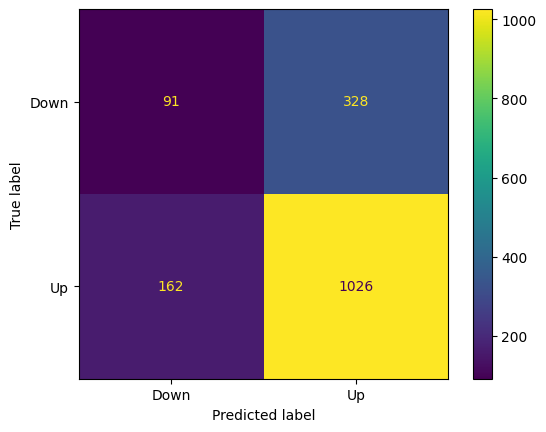

In [16]:
### DMoodley correction
from sklearn.metrics import ConfusionMatrixDisplay

cm = metrics.confusion_matrix(y_test.values, y_pred[:,0])
disp = ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"])
disp.plot()

### **3.2 Trading strategy based on model predictions**

Next, let's evaluate the extent to which our model predictions can act as the foundation of a trading strategy. To that end, we will perform a **backtest** in the same spirit of Module 7 in Machine Learning:

In [17]:
df_predictions = pd.DataFrame(
    {
        'Date': test_time,  # No flatten needed for DatetimeIndex
        'Pred': y_pred.flatten() if y_pred.ndim > 1 else y_pred,  # Flatten if 2D
        'Ret': Ret_vector.flatten() if Ret_vector.ndim > 1 else Ret_vector,  # Flatten if 2D
    }
)
df_predictions.tail()

,Date,Pred,Ret
1602,2025-04-30,0,0.61
1603,2025-05-01,0,0.39
1604,2025-05-02,0,-3.74
1605,2025-05-05,0,-3.15
1606,2025-05-06,0,-0.19


We will define the positions that our trading strategy will take as long ($+1$) if the prediction of the model is higher than $0.5$, and short ($-1$) if less. *(Note, nonetheless, that in practice our prediction can only take values 0 or 1)*

As in previous cases, we will backtest 3 trading strategies:

- A long/short strategy that will take a long or short position when model prediction indicate so.

- A long-only strategy that will go to cash (return = 0) when model predicts a negative 120-day return.

- A Buy-and-hold strategy that will buy the stock at the beginning of the test period and hold it until the end of the period.

In [18]:
df = df_predictions

df['Ret'] = df['Ret'] / 100

df["Positions"] = np.where(df["Pred"] > 0.5, 1, -1)
df["Strat_ret"] = df["Positions"].shift(1) * df["Ret"]
df["Positions_L"] = df["Positions"].shift(1)
df["Positions_L"][df["Positions_L"] == -1] = 0
df["Strat_ret_L"] = df["Positions_L"] * df["Ret"]
df["CumRet"] = df["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["CumRet_L"] = df["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["bhRet"] = df["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

Final_Return_L = np.prod(1 + df["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df["Ret"]) - 1

print("Strat Return Long Only =", Final_Return_L * 100, "%")
print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

/tmp/ipykernel_5841/2685361883.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Positions_L"][df["Positions_L"] == -1] = 0


Strat Return Long Only = 313.1173394983836 %
Strat Return = 194.30818715943187 %
Buy and Hold Return = 376.11163150377774 %


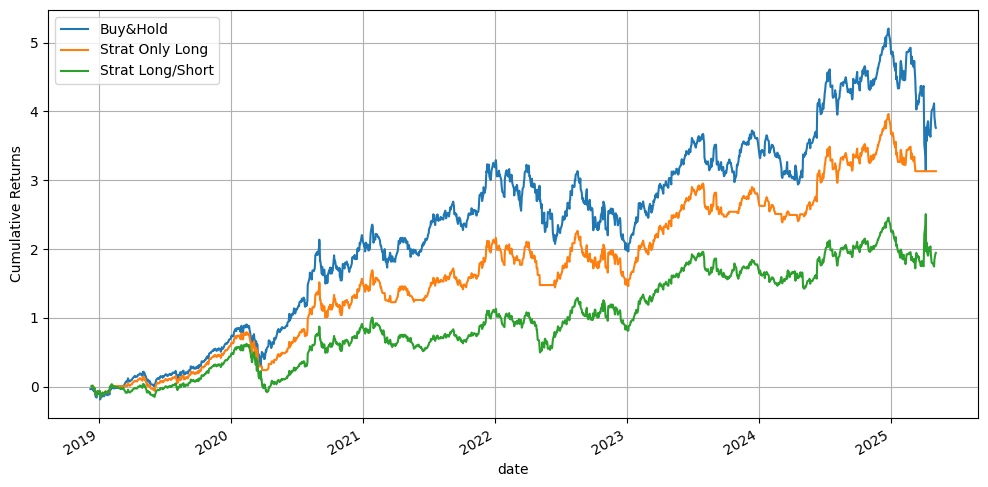

,Date,Pred,Ret,Positions,Strat_ret,Positions_L,Strat_ret_L,CumRet,CumRet_L,bhRet
count,1607,1607.000000,1607.000000,1607.000000,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000,1607.000000
mean,2022-02-18 12:06:43.235843328,0.842564,0.001174,0.685128,0.000877,0.843088,0.001037,0.976935,1.700314,2.328598
min,2018-12-07 00:00:00,0.000000,-0.128600,-1.000000,-0.153300,0.000000,-0.128600,-0.156117,-0.156117,-0.186244
25%,2020-07-15 12:00:00,1.000000,-0.008150,1.000000,-0.008300,1.000000,-0.005900,0.531523,0.791044,1.225672
50%,2022-02-16 00:00:00,1.000000,0.001500,1.000000,0.001150,1.000000,0.000000,0.897106,1.677941,2.488385
75%,2023-09-26 12:00:00,1.000000,0.011900,1.000000,0.011600,1.000000,0.009000,1.613472,2.541385,3.233868
max,2025-05-06 00:00:00,1.000000,0.153300,1.000000,0.119800,1.000000,0.119800,2.506969,3.963271,5.205463
std,NaN,0.364325,0.020169,0.728650,0.020171,0.363831,0.017512,0.677663,1.050868,1.368053


In [19]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df.plot(x="Date", y="bhRet", label="Buy&Hold", ax=ax)
df.plot(x="Date", y="CumRet_L", label="Strat Only Long", ax=ax)
df.plot(x="Date", y="CumRet", label="Strat Long/Short", ax=ax)
plt.xlabel("date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

df.describe()

## **4. Conclusion**

In this lesson, we have worked with TensorFlow Keras on a MLP model for classification purposes. Specifically, we designed a MLP model that aims to predict the forward 120 day return of Apple stock. In doing so, we have introduced some novel features of Deep Learning models, such as dropout and class weights, which will also come in handy later on for improving the performance of our models. Still, there is much to be done in terms of improving model performance by, for example, optimally selecting some of the hyperparameters used in the model such as the learning rate. That is what we will do in the remainder of the module introducing hyperparameter tuning. For that, see you in the next lesson!

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
